# Terrain Modifications: High-Ground and Polygon Writer Validation

This notebook validates ras-commander terrain modification writers with a real HEC-RAS example project. It creates copied terrain sidecar modifications for high-ground lines, boundary-sampled polygon multipoint grading, and `shape_z` polygon grading, verifies raster readback, runs HEC-RAS through `RasCmdr.compute_plan()`, and compares maximum water surface elevation impacts.


## Workflow

1. Extract isolated copies of the BaldEagleCrkMulti2D example project.
2. Add a `take_higher` high-ground line modification with a 6 ft raise to the proposed copy.
3. Add a boundary-from-terrain polygon multipoint grading area with interior control points set to existing grade plus 5 ft and plus 3 ft.
4. Add a second polygon example using `elevation_method='shape_z'` with ring Z values set to sampled existing grade plus 4 ft.
5. Verify HDF and `.rasmap` metadata for both polygon writer paths.
6. Plot writer-computed and raster-read before/after terrain profiles.
7. Map modified terrain at geometry cell centers.
8. Run base, high-ground, multipoint polygon, and shape_z polygon plan 18 with geometry preprocessing forced.
9. Compare maximum WSE results from the computed plan HDF files and identify benefit/rise polygons with `HdfBenefitAreas`.


In [1]:
# Development-source setup and imports
from pathlib import Path
import logging
import shutil
import sys
import warnings
import xml.etree.ElementTree as ET

import h5py
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import matplotlib.tri as mtri
import numpy as np
import pandas as pd

candidates = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(path for path in candidates if (path / 'ras_commander').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ras_commander import HdfBenefitAreas, HdfMesh, HdfResultsMesh, RasCmdr, RasExamples, init_ras_project
from ras_commander.terrain import RasTerrainMod, RasTerrainModification, RasTerrainModWriter

logging.getLogger('ras_commander').setLevel(logging.WARNING)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.display.max_columns = 20

NOTEBOOK_DIR = REPO_ROOT / 'examples'
ARTIFACT_ROOT = NOTEBOOK_DIR / 'example_projects' / '316_terrain_modifications'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Repository: {REPO_ROOT}')
print(f'Artifacts:  {ARTIFACT_ROOT.relative_to(REPO_ROOT)}')


Repository: G:\GH\ras-commander
Artifacts:  examples\example_projects\316_terrain_modifications


In [2]:
# Extract isolated base/proposed/polygon project copies
template = RasExamples.extract_project(
    'BaldEagleCrkMulti2D',
    output_path=ARTIFACT_ROOT,
    suffix='template',
)
base_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_base'
proposed_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_proposed'
polygon_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_polygon_multipoint'
shape_z_project = ARTIFACT_ROOT / 'BaldEagleCrkMulti2D_polygon_shape_z'
for project in (base_project, proposed_project, polygon_project, shape_z_project):
    if project.exists():
        shutil.rmtree(project)
    shutil.copytree(template, project)

base_ras = init_ras_project(base_project, '6.6', ras_object='new', load_results_summary=False)
proposed_ras = init_ras_project(proposed_project, '6.6', ras_object='new', load_results_summary=False)
polygon_ras = init_ras_project(polygon_project, '6.6', ras_object='new', load_results_summary=False)
shape_z_ras = init_ras_project(shape_z_project, '6.6', ras_object='new', load_results_summary=False)

plan_number = '18'
plan_row = base_ras.plan_df.loc[base_ras.plan_df['plan_number'] == plan_number].iloc[0]
geom_number = str(plan_row['Geom File'])
base_geom_hdf = Path(base_ras.geom_df.loc[base_ras.geom_df['geom_number'] == geom_number, 'hdf_path'].iloc[0])
proposed_geom_hdf = proposed_project / base_geom_hdf.name
polygon_geom_hdf = polygon_project / base_geom_hdf.name
shape_z_geom_hdf = shape_z_project / base_geom_hdf.name
terrain_value = proposed_ras.rasmap_df['terrain_hdf_path'].iloc[0]
proposed_terrain_hdf = Path(terrain_value[0] if isinstance(terrain_value, list) else terrain_value)
polygon_terrain_value = polygon_ras.rasmap_df['terrain_hdf_path'].iloc[0]
polygon_terrain_hdf = Path(
    polygon_terrain_value[0]
    if isinstance(polygon_terrain_value, list)
    else polygon_terrain_value
)
shape_z_terrain_value = shape_z_ras.rasmap_df['terrain_hdf_path'].iloc[0]
shape_z_terrain_hdf = Path(
    shape_z_terrain_value[0]
    if isinstance(shape_z_terrain_value, list)
    else shape_z_terrain_value
)

summary = pd.DataFrame([
    {'condition': 'base', 'project': str(base_project), 'geom_hdf': str(base_geom_hdf)},
    {'condition': 'high-ground proposed', 'project': str(proposed_project), 'terrain_hdf': str(proposed_terrain_hdf)},
    {'condition': 'polygon multipoint proposed', 'project': str(polygon_project), 'terrain_hdf': str(polygon_terrain_hdf)},
    {'condition': 'shape_z polygon example', 'project': str(shape_z_project), 'terrain_hdf': str(shape_z_terrain_hdf)},
])
summary

,condition,project,geom_hdf,terrain_hdf
0,base,G:\GH\ras-commander\examples\example_projects\...,G:\GH\ras-commander\examples\example_projects\...,NaN
1,high-ground proposed,G:\GH\ras-commander\examples\example_projects\...,NaN,G:\GH\ras-commander\examples\example_projects\...
2,polygon multipoint proposed,G:\GH\ras-commander\examples\example_projects\...,NaN,G:\GH\ras-commander\examples\example_projects\...
3,shape_z polygon example,G:\GH\ras-commander\examples\example_projects\...,NaN,G:\GH\ras-commander\examples\example_projects\...


In [3]:
# Define a levee/road alignment across the BaldEagleCr 2D flow area
mesh_areas = HdfMesh.get_mesh_areas(base_geom_hdf)
target_area = mesh_areas.loc[mesh_areas['mesh_name'] == 'BaldEagleCr'].iloc[0]
minx, miny, maxx, maxy = target_area.geometry.bounds
line_y = miny + 0.55 * (maxy - miny)
profile_x = [minx + 0.15 * (maxx - minx), maxx - 0.15 * (maxx - minx)]
profile_y = [line_y, line_y]
high_ground_raise_ft = 6.0

RasTerrainMod.setup_gdal_bridge('6.6')
baseline_profile = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=4.0,
)
profile_points = baseline_profile[['station', 'elevation']].to_numpy(dtype=float).copy()
profile_points[:, 1] += high_ground_raise_ft
mod_line = np.array([[profile_x[0], profile_y[0]], [profile_x[1], profile_y[1]]], dtype=float)

RasTerrainModWriter.add_high_ground_modification(
    terrain_hdf_path=proposed_terrain_hdf,
    rasmap_path=proposed_project / 'BaldEagleDamBrk.rasmap',
    name='API High Ground Levee',
    polyline_points=mod_line,
    profile_points=profile_points,
    top_width=120.0,
    side_slope=4.0,
    max_extent=600.0,
    elev_pt_tolerance=4.0,
)

mods = RasTerrainModWriter.list_modifications(proposed_terrain_hdf)
rasmap_text = (proposed_project / 'BaldEagleDamBrk.rasmap').read_text(encoding='utf-8')
print('Modification registered in .rasmap:', 'API High Ground Levee' in rasmap_text)
mods


Modification registered in .rasmap: True


,name,type,subtype,priority,modification_type,modification_mode,width,left_slope,right_slope,max_extent,elev_pt_tolerance,profile_points
0,API High Ground Levee,Levee,Levee,0,1,take_higher,120.0,4.0,4.0,600.0,4.0,260


,terrain_difference_ft
count,2.600000e+02
mean,6.000000e+00
std,5.025337e-13
min,6.000000e+00
25%,6.000000e+00
50%,6.000000e+00
75%,6.000000e+00
max,6.000000e+00


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/terrain_profile_difference.png')

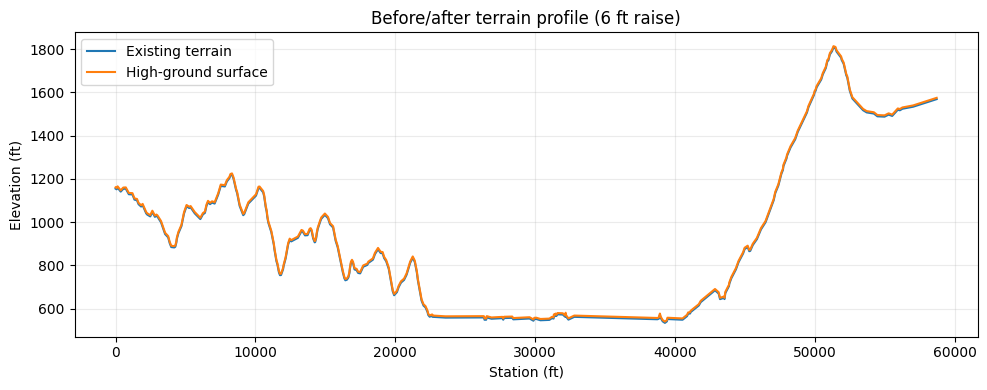

In [4]:
# Before/after terrain profile from the writer-side verification helper
profile_compare = RasTerrainModWriter.apply_modification_to_profile(
    proposed_terrain_hdf,
    'API High Ground Levee',
    baseline_profile,
    x_coords=profile_x,
    y_coords=profile_y,
)
profile_stats = profile_compare['difference'].describe().to_frame('terrain_difference_ft')
display(profile_stats)
assert profile_compare['difference'].max() <= 8.0
assert profile_compare['difference'].max() >= 5.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile_compare['station'], profile_compare['existing_elevation'], label='Existing terrain')
ax.plot(profile_compare['station'], profile_compare['proposed_elevation'], label='High-ground surface')
ax.fill_between(
    profile_compare['station'],
    profile_compare['existing_elevation'],
    profile_compare['proposed_elevation'],
    where=profile_compare['difference'] > 0,
    alpha=0.25,
)
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title(f'Before/after terrain profile ({high_ground_raise_ft:.0f} ft raise)')
ax.legend()
ax.grid(True, alpha=0.25)
profile_png = ARTIFACT_ROOT / 'terrain_profile_difference.png'
fig.tight_layout()
fig.savefig(profile_png, dpi=160)
profile_png


,count,mean,std,min,25%,50%,75%,max
writer_difference,6995.0,5.912489e+00,1.510301,0.633742,5.043287,6.0,6.728656,9.983736
raster_writer_difference,6995.0,-1.294628e-08,0.000012,-0.000059,0.000000,0.0,0.000000,0.000060
raster_change_ft,6995.0,5.912489e+00,1.510301,0.633746,5.043276,6.0,6.728654,9.983736


Max writer-vs-raster profile difference: 0.000060 ft
High-ground raster terrain change range: 0.634 to 9.984 ft


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/terrain_profile_readback_validation.png')

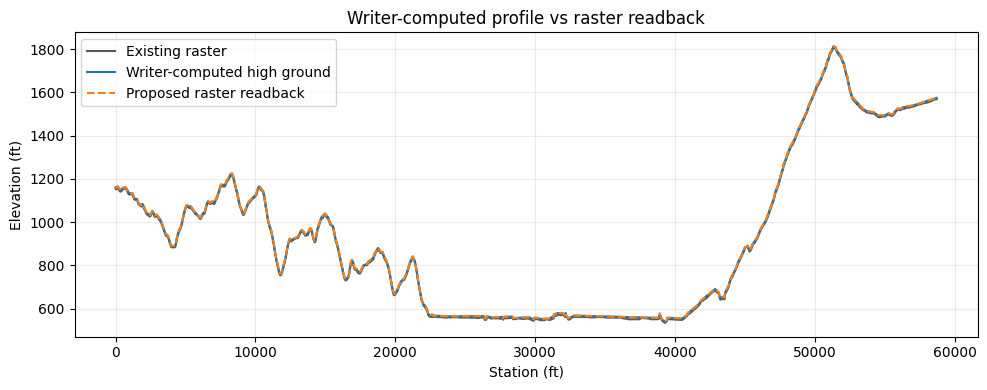

In [5]:
# Read the proposed terrain back through RasMapperLib and compare to writer expectation
readback_filter_tolerance = 0.01
readback_existing = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=readback_filter_tolerance,
)
readback_proposed = RasTerrainMod.get_terrain_profile(
    proposed_project / 'BaldEagleDamBrk.rasmap',
    proposed_geom_hdf,
    profile_x,
    profile_y,
    filter_tolerance=readback_filter_tolerance,
)
assert not readback_existing.empty, 'Base raster-read terrain profile is empty'
assert not readback_proposed.empty, 'Proposed raster-read terrain profile is empty'

writer_readback_compare = RasTerrainModWriter.apply_modification_to_profile(
    proposed_terrain_hdf,
    'API High Ground Levee',
    readback_existing[['station', 'elevation']],
    x_coords=profile_x,
    y_coords=profile_y,
)
raster_proposed_elevation = np.interp(
    writer_readback_compare['station'].to_numpy(dtype=float),
    readback_proposed['station'].to_numpy(dtype=float),
    readback_proposed['elevation'].to_numpy(dtype=float),
)
readback_validation = writer_readback_compare[[
    'station',
    'x',
    'y',
    'existing_elevation',
    'proposed_elevation',
    'difference',
]].copy()
readback_validation = readback_validation.rename(columns={
    'proposed_elevation': 'writer_proposed_elevation',
    'difference': 'writer_difference',
})
readback_validation['raster_read_elevation'] = raster_proposed_elevation
readback_validation['raster_writer_difference'] = (
    readback_validation['raster_read_elevation']
    - readback_validation['writer_proposed_elevation']
)
readback_validation['raster_change_ft'] = (
    readback_validation['raster_read_elevation']
    - readback_validation['existing_elevation']
)
readback_max_abs_diff = float(
    readback_validation['raster_writer_difference'].abs().max()
)
readback_max_change = float(readback_validation['raster_change_ft'].max())
readback_min_change = float(readback_validation['raster_change_ft'].min())
readback_tolerance_ft = 0.01
readback_stats = readback_validation[
    ['writer_difference', 'raster_writer_difference', 'raster_change_ft']
].describe().T
display(readback_stats)
print(f'Max writer-vs-raster profile difference: {readback_max_abs_diff:.6f} ft')
print(f'High-ground raster terrain change range: {readback_min_change:.3f} to {readback_max_change:.3f} ft')
assert readback_max_abs_diff <= readback_tolerance_ft, (
    f'Raster-read profile differs from writer-computed profile by '
    f'{readback_max_abs_diff:.6f} ft, exceeding {readback_tolerance_ft:.3f} ft'
)
assert readback_max_change <= 10.0, (
    f'High-ground raster terrain change exceeds 10 ft: {readback_max_change:.3f} ft'
)
assert readback_max_change >= 5.0, 'High-ground modification did not produce a measurable raise'

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    readback_validation['station'],
    readback_validation['existing_elevation'],
    label='Existing raster',
    color='0.35',
)
ax.plot(
    readback_validation['station'],
    readback_validation['writer_proposed_elevation'],
    label='Writer-computed high ground',
    color='tab:blue',
)
ax.plot(
    readback_validation['station'],
    readback_validation['raster_read_elevation'],
    label='Proposed raster readback',
    color='tab:orange',
    linestyle='--',
)
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('Writer-computed profile vs raster readback')
ax.legend()
ax.grid(True, alpha=0.25)
readback_profile_png = ARTIFACT_ROOT / 'terrain_profile_readback_validation.png'
fig.tight_layout()
fig.savefig(readback_profile_png, dpi=160)
readback_profile_png

2026-06-30 15:22:21 - rasterio._env - WARNING - CPLE_AppDefined in PROJ: proj_create_from_database: C:\Program Files (x86)\HEC\HEC-RAS\6.6\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


2026-06-30 15:22:21 - rasterio._env - WARNING - CPLE_AppDefined in PROJ: proj_create_from_name: C:\Program Files (x86)\HEC\HEC-RAS\6.6\GDAL\common\data\proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


,modification,dataset,count,min_elevation_ft,max_elevation_ft
0,API Multipoint Wetland Fill,boundary vertices,5,564.843750,573.062500
1,API Multipoint Wetland Fill,interior controls,2,568.876953,570.660278
2,API Multipoint Wetland Fill,profile values,5,564.843750,573.062500
3,API Shape Z Wetland Fill,boundary vertices,5,763.179932,765.740478
4,API Shape Z Wetland Fill,profile values,5,763.179932,765.740479


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/polygon_multipoint_control_points.png')

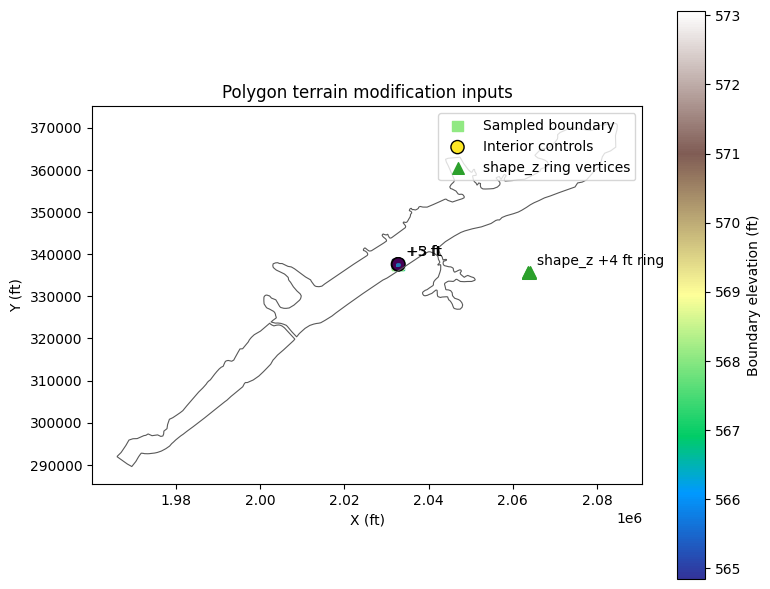

In [6]:
# Polygon multipoint terrain modification writer validation
base_rasmap = base_project / 'BaldEagleDamBrk.rasmap'
polygon_name = 'API Multipoint Wetland Fill'
poly_cx = minx + 0.38 * (maxx - minx)
poly_cy = miny + 0.34 * (maxy - miny)
poly_w = 0.004 * (maxx - minx)
poly_h = 0.004 * (maxy - miny)
polygon_coords = np.array(
    [
        [poly_cx - 0.5 * poly_w, poly_cy - 0.5 * poly_h],
        [poly_cx + 0.5 * poly_w, poly_cy - 0.5 * poly_h],
        [poly_cx + 0.5 * poly_w, poly_cy + 0.5 * poly_h],
        [poly_cx - 0.5 * poly_w, poly_cy + 0.5 * poly_h],
    ],
    dtype=float,
)
control_xy = np.array(
    [
        [poly_cx - 0.18 * poly_w, poly_cy],
        [poly_cx + 0.18 * poly_w, poly_cy],
    ],
    dtype=float,
)
control_existing_profile = RasTerrainMod.get_terrain_profile(
    base_rasmap,
    base_geom_hdf,
    control_xy[:, 0].tolist(),
    control_xy[:, 1].tolist(),
    filter_tolerance=0.0,
)
control_stations = np.r_[
    0.0,
    np.cumsum(np.hypot(np.diff(control_xy[:, 0]), np.diff(control_xy[:, 1]))),
]
control_existing_elevations = np.interp(
    control_stations,
    control_existing_profile['station'].to_numpy(dtype=float),
    control_existing_profile['elevation'].to_numpy(dtype=float),
)
polygon_control_raises = np.array([5.0, 3.0], dtype=float)
polygon_control_elevations = control_existing_elevations + polygon_control_raises
polygon_control_points = [
    {
        'x': float(x),
        'y': float(y),
        'elevation': float(elevation),
        'name': f'Wetland fill +{raise_ft:.0f} ft',
    }
    for (x, y), elevation, raise_ft in zip(
        control_xy,
        polygon_control_elevations,
        polygon_control_raises,
    )
]

RasTerrainModification.add_modification_polygon(
    terrain_hdf_path=polygon_terrain_hdf,
    name=polygon_name,
    polygon_coords=polygon_coords,
    elevation_method='boundary_from_terrain',
    control_points=polygon_control_points,
    rasmap_path=polygon_project / 'BaldEagleDamBrk.rasmap',
    elev_pt_tolerance=15.0,
)

shape_z_name = 'API Shape Z Wetland Fill'
# Keep the shape_z writer example outside the active 2D mesh so it validates
# the alternate polygon writer path and HEC-RAS compute compatibility without
# introducing a second hydraulic perturbation.
shape_z_cx = minx + 0.75 * (maxx - minx)
shape_z_cy = miny + 0.30 * (maxy - miny)
shape_z_w = 0.004 * (maxx - minx)
shape_z_h = 0.004 * (maxy - miny)
shape_z_raise_ft = 4.0
shape_z_ring_xy = np.array(
    [
        [shape_z_cx - 0.5 * shape_z_w, shape_z_cy - 0.5 * shape_z_h],
        [shape_z_cx + 0.5 * shape_z_w, shape_z_cy - 0.5 * shape_z_h],
        [shape_z_cx + 0.5 * shape_z_w, shape_z_cy + 0.5 * shape_z_h],
        [shape_z_cx - 0.5 * shape_z_w, shape_z_cy + 0.5 * shape_z_h],
    ],
    dtype=float,
)
shape_z_closed_xy = np.vstack([shape_z_ring_xy, shape_z_ring_xy[0]])
shape_z_ring_profile = RasTerrainMod.get_terrain_profile(
    base_rasmap,
    base_geom_hdf,
    shape_z_closed_xy[:, 0].tolist(),
    shape_z_closed_xy[:, 1].tolist(),
    filter_tolerance=0.0,
)
shape_z_ring_stations = np.r_[
    0.0,
    np.cumsum(
        np.hypot(
            np.diff(shape_z_closed_xy[:, 0]),
            np.diff(shape_z_closed_xy[:, 1]),
        )
    ),
]
shape_z_existing_ring_elevations = np.interp(
    shape_z_ring_stations[:-1],
    shape_z_ring_profile['station'].to_numpy(dtype=float),
    shape_z_ring_profile['elevation'].to_numpy(dtype=float),
)
shape_z_polygon_coords = np.column_stack(
    [shape_z_ring_xy, shape_z_existing_ring_elevations + shape_z_raise_ft]
)
shape_z_center_elevation = float(np.mean(shape_z_existing_ring_elevations))
shape_z_control_points = [
    {
        'x': float(shape_z_cx),
        'y': float(shape_z_cy),
        'elevation': shape_z_center_elevation + shape_z_raise_ft,
        'name': f'shape_z center +{shape_z_raise_ft:.0f} ft',
    }
]
RasTerrainModification.add_modification_polygon(
    terrain_hdf_path=shape_z_terrain_hdf,
    name=shape_z_name,
    polygon_coords=shape_z_polygon_coords,
    elevation_method='shape_z',
    control_points=shape_z_control_points,
    rasmap_path=shape_z_project / 'BaldEagleDamBrk.rasmap',
    elev_pt_tolerance=10.0,
)

with h5py.File(polygon_terrain_hdf, 'r') as hdf:
    mod = hdf[f'Modifications/{polygon_name}']
    boundary_xyz = mod['Boundary Points'][:]
    control_xyz = mod['Control Points/Elevation Points'][:]
    profile_values = mod['Profile Values'][:]
    polygon_attrs = mod['Attributes'][0]

assert np.all(np.isfinite(boundary_xyz)), 'Boundary elevations must be finite'
np.testing.assert_allclose(control_xyz[:, 2], polygon_control_elevations, atol=1e-6)
assert int(polygon_attrs['Generate Boundary Elevations']) == 1
assert int(polygon_attrs['Use ShapeFile Z Elevations']) == 0

root = ET.parse(polygon_project / 'BaldEagleDamBrk.rasmap').getroot()
polygon_layers = [
    layer for layer in root.findall('.//Layer')
    if layer.get('Name') == polygon_name
]
assert len(polygon_layers) == 1
assert polygon_layers[0].get('Type') == 'PolygonElevationModificationLayer'

with h5py.File(shape_z_terrain_hdf, 'r') as hdf:
    shape_z_mod = hdf[f'Modifications/{shape_z_name}']
    shape_z_boundary_xyz = shape_z_mod['Boundary Points'][:]
    shape_z_profile_values = shape_z_mod['Profile Values'][:]
    shape_z_attrs = shape_z_mod['Attributes'][0]

shape_z_expected = np.r_[shape_z_polygon_coords[:, 2], shape_z_polygon_coords[0, 2]]
np.testing.assert_allclose(shape_z_boundary_xyz[:, 2], shape_z_expected, atol=1e-6)
np.testing.assert_allclose(shape_z_profile_values[:, 1], shape_z_expected, atol=1e-6)
assert int(shape_z_attrs['Generate Boundary Elevations']) == 0
assert int(shape_z_attrs['Use ShapeFile Z Elevations']) == 1

shape_z_root = ET.parse(shape_z_project / 'BaldEagleDamBrk.rasmap').getroot()
shape_z_layers = [
    layer for layer in shape_z_root.findall('.//Layer')
    if layer.get('Name') == shape_z_name
]
assert len(shape_z_layers) == 1
assert shape_z_layers[0].get('Type') == 'PolygonElevationModificationLayer'

polygon_summary = pd.DataFrame({
    'modification': [polygon_name, polygon_name, polygon_name, shape_z_name, shape_z_name],
    'dataset': ['boundary vertices', 'interior controls', 'profile values', 'boundary vertices', 'profile values'],
    'count': [
        len(boundary_xyz),
        len(control_xyz),
        len(profile_values),
        len(shape_z_boundary_xyz),
        len(shape_z_profile_values),
    ],
    'min_elevation_ft': [
        float(boundary_xyz[:, 2].min()),
        float(control_xyz[:, 2].min()),
        float(profile_values[:, 1].min()),
        float(shape_z_boundary_xyz[:, 2].min()),
        float(shape_z_profile_values[:, 1].min()),
    ],
    'max_elevation_ft': [
        float(boundary_xyz[:, 2].max()),
        float(control_xyz[:, 2].max()),
        float(profile_values[:, 1].max()),
        float(shape_z_boundary_xyz[:, 2].max()),
        float(shape_z_profile_values[:, 1].max()),
    ],
})
display(polygon_summary)

fig, ax = plt.subplots(figsize=(8, 6))
mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.35')
closed_polygon = np.vstack([polygon_coords, polygon_coords[0]])
ax.plot(closed_polygon[:, 0], closed_polygon[:, 1], color='tab:blue', linewidth=2.0)
shape_z_closed_polygon = np.vstack([shape_z_polygon_coords[:, :2], shape_z_polygon_coords[0, :2]])
ax.plot(shape_z_closed_polygon[:, 0], shape_z_closed_polygon[:, 1], color='tab:green', linewidth=2.0)
sc_boundary = ax.scatter(
    boundary_xyz[:, 0],
    boundary_xyz[:, 1],
    c=boundary_xyz[:, 2],
    cmap='terrain',
    marker='s',
    s=55,
    label='Sampled boundary',
)
sc_control = ax.scatter(
    control_xyz[:, 0],
    control_xyz[:, 1],
    c=control_xyz[:, 2],
    cmap='viridis',
    marker='o',
    edgecolor='black',
    s=90,
    label='Interior controls',
)
ax.scatter(
    shape_z_boundary_xyz[:, 0],
    shape_z_boundary_xyz[:, 1],
    color='tab:green',
    marker='^',
    s=70,
    label='shape_z ring vertices',
)
for point, raise_ft in zip(control_xyz, polygon_control_raises):
    ax.annotate(f'+{raise_ft:.0f} ft', xy=(point[0], point[1]), xytext=(6, 6), textcoords='offset points')
ax.annotate(f'shape_z +{shape_z_raise_ft:.0f} ft ring', xy=(shape_z_cx, shape_z_cy), xytext=(6, 6), textcoords='offset points')
ax.set_aspect('equal')
ax.set_title('Polygon terrain modification inputs')
ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
ax.legend(loc='upper right')
fig.colorbar(sc_boundary, ax=ax, label='Boundary elevation (ft)')
polygon_points_png = ARTIFACT_ROOT / 'polygon_multipoint_control_points.png'
fig.tight_layout()
fig.savefig(polygon_points_png, dpi=160)
polygon_points_png


,target_x,target_y,target_elevation_ft,readback_station_ft,readback_elevation_ft,readback_minus_target_ft,profile_distance_ft
0,2.032737e+06,337601.921003,570.660278,224.743301,570.660278,0.0,0.000006
1,2.032858e+06,337601.921003,568.876953,345.500885,568.876953,0.0,0.000002


,count,mean,std,min,25%,50%,75%,max,inside_profile_points,max_abs_ft
readback_difference,157.0,3.568489,1.108918,0.743785,3.072388,3.403687e+00,4.497009,5.009216,157,5.009216
raster_minus_expected_tin_ft,157.0,0.000002,0.000017,-0.000029,-0.000014,1.113549e-07,0.000015,0.000031,157,0.000031


Polygon profile points inside footprint: 157
Control-point nearest raster max abs diff: 0.000000 ft
Polygon raster-vs-independent-TIN max abs diff: 0.000031 ft


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/polygon_profile_readback_validation.png')

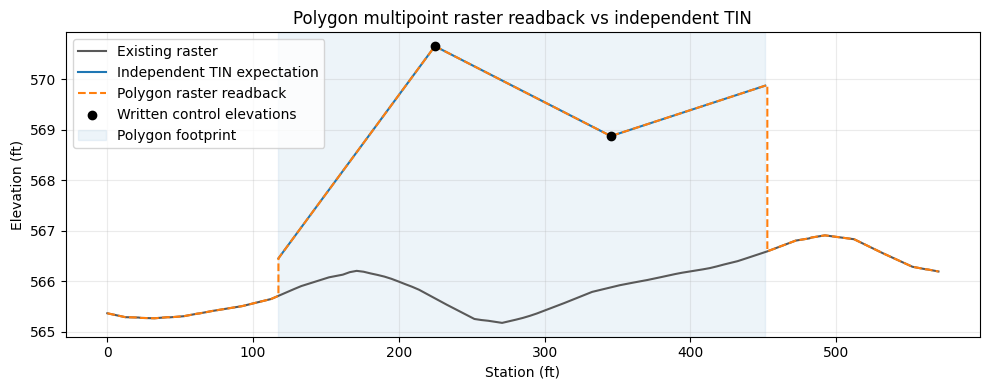

In [7]:
# Read the polygon modification back through RasMapperLib and compare profile response
def interpolate_tin_surface(points_xyz, sample_x, sample_y):
    surface_points = (
        pd.DataFrame(points_xyz, columns=['x', 'y', 'elevation'])
        .drop_duplicates(subset=['x', 'y'], keep='first')
    )
    triangulation = mtri.Triangulation(
        surface_points['x'].to_numpy(dtype=float),
        surface_points['y'].to_numpy(dtype=float),
    )
    interpolator = mtri.LinearTriInterpolator(
        triangulation,
        surface_points['elevation'].to_numpy(dtype=float),
    )
    values = interpolator(np.asarray(sample_x, dtype=float), np.asarray(sample_y, dtype=float))
    return np.asarray(np.ma.filled(values, np.nan), dtype=float)

polygon_profile_x = np.linspace(poly_cx - 0.85 * poly_w, poly_cx + 0.85 * poly_w, 121).tolist()
polygon_profile_y = [poly_cy] * len(polygon_profile_x)
polygon_profile_tolerance = 0.0
polygon_existing_profile = RasTerrainMod.get_terrain_profile(
    base_project / 'BaldEagleDamBrk.rasmap',
    base_geom_hdf,
    polygon_profile_x,
    polygon_profile_y,
    filter_tolerance=polygon_profile_tolerance,
)
polygon_readback_profile = RasTerrainMod.get_terrain_profile(
    polygon_project / 'BaldEagleDamBrk.rasmap',
    polygon_geom_hdf,
    polygon_profile_x,
    polygon_profile_y,
    filter_tolerance=polygon_profile_tolerance,
)
assert not polygon_existing_profile.empty, 'Base polygon profile is empty'
assert not polygon_readback_profile.empty, 'Polygon readback profile is empty'

polygon_stations = polygon_readback_profile['station'].to_numpy(dtype=float)
polygon_existing_interp = np.interp(
    polygon_stations,
    polygon_existing_profile['station'].to_numpy(dtype=float),
    polygon_existing_profile['elevation'].to_numpy(dtype=float),
)
profile_length = float(np.hypot(
    polygon_profile_x[-1] - polygon_profile_x[0],
    polygon_profile_y[-1] - polygon_profile_y[0],
))
polygon_sample_x = (
    polygon_profile_x[0]
    + (polygon_stations / profile_length)
    * (polygon_profile_x[-1] - polygon_profile_x[0])
)
polygon_sample_y = (
    polygon_profile_y[0]
    + (polygon_stations / profile_length)
    * (polygon_profile_y[-1] - polygon_profile_y[0])
)
inside_polygon = MplPath(boundary_xyz[:-1, :2]).contains_points(
    np.column_stack([polygon_sample_x, polygon_sample_y]),
    radius=1e-6,
)
inside_polygon_count = int(inside_polygon.sum())
assert inside_polygon_count > 3, (
    f'Expected more than 3 profile points inside polygon; got {inside_polygon_count}'
)
expected_polygon_surface = interpolate_tin_surface(
    np.vstack([boundary_xyz, control_xyz]),
    polygon_sample_x,
    polygon_sample_y,
)
polygon_validation = polygon_readback_profile[['station', 'elevation']].copy()
polygon_validation = polygon_validation.rename(columns={'elevation': 'raster_read_elevation'})
polygon_validation['x'] = polygon_sample_x
polygon_validation['y'] = polygon_sample_y
polygon_validation['existing_elevation'] = polygon_existing_interp
polygon_validation['expected_tin_elevation'] = expected_polygon_surface
polygon_validation['inside_polygon'] = inside_polygon
polygon_validation['readback_difference'] = (
    polygon_validation['raster_read_elevation']
    - polygon_validation['existing_elevation']
)
polygon_validation['raster_minus_expected_tin_ft'] = (
    polygon_validation['raster_read_elevation']
    - polygon_validation['expected_tin_elevation']
)
inside_validation = polygon_validation[
    polygon_validation['inside_polygon']
    & np.isfinite(polygon_validation['expected_tin_elevation'])
].copy()
assert not inside_validation.empty, 'Polygon raster profile had no finite points inside the footprint'
polygon_max_abs_change = float(inside_validation['readback_difference'].abs().max())
polygon_max_abs_tin_diff = float(inside_validation['raster_minus_expected_tin_ft'].abs().max())
assert polygon_max_abs_change <= 10.0, (
    f'Polygon terrain change exceeds 10 ft: {polygon_max_abs_change:.3f} ft'
)
assert polygon_max_abs_change >= 2.0, 'Polygon modification did not produce a measurable terrain change'
polygon_raster_tin_tolerance_ft = 1.0
assert polygon_max_abs_tin_diff <= polygon_raster_tin_tolerance_ft, (
    f'Polygon raster-read profile differs from independent TIN expectation by '
    f'{polygon_max_abs_tin_diff:.6f} ft'
)

control_checks = []
for control_point in control_xyz:
    distance = np.hypot(
        polygon_validation['x'].to_numpy(dtype=float) - control_point[0],
        polygon_validation['y'].to_numpy(dtype=float) - control_point[1],
    )
    nearest_idx = int(np.argmin(distance))
    row = polygon_validation.iloc[nearest_idx]
    control_checks.append({
        'target_x': float(control_point[0]),
        'target_y': float(control_point[1]),
        'target_elevation_ft': float(control_point[2]),
        'readback_station_ft': float(row['station']),
        'readback_elevation_ft': float(row['raster_read_elevation']),
        'readback_minus_target_ft': float(row['raster_read_elevation'] - control_point[2]),
        'profile_distance_ft': float(distance[nearest_idx]),
    })
control_check_df = pd.DataFrame(control_checks)
control_max_abs_diff = float(control_check_df['readback_minus_target_ft'].abs().max())
assert control_max_abs_diff <= 1.5, (
    f'Nearest raster profile point differs from control elevations by '
    f'{control_max_abs_diff:.6f} ft'
)

polygon_profile_stats = inside_validation[[
    'readback_difference',
    'raster_minus_expected_tin_ft',
]].describe().T
polygon_profile_stats['inside_profile_points'] = inside_polygon_count
polygon_profile_stats['max_abs_ft'] = [
    polygon_max_abs_change,
    polygon_max_abs_tin_diff,
]
display(control_check_df)
display(polygon_profile_stats)
print(f'Polygon profile points inside footprint: {inside_polygon_count}')
print(f'Control-point nearest raster max abs diff: {control_max_abs_diff:.6f} ft')
print(f'Polygon raster-vs-independent-TIN max abs diff: {polygon_max_abs_tin_diff:.6f} ft')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    polygon_validation['station'],
    polygon_validation['existing_elevation'],
    label='Existing raster',
    color='0.35',
)
ax.plot(
    polygon_validation['station'],
    polygon_validation['expected_tin_elevation'],
    label='Independent TIN expectation',
    color='tab:blue',
)
ax.plot(
    polygon_validation['station'],
    polygon_validation['raster_read_elevation'],
    label='Polygon raster readback',
    color='tab:orange',
    linestyle='--',
)
control_station = [
    float(np.hypot(point[0] - polygon_profile_x[0], point[1] - polygon_profile_y[0]))
    for point in control_xyz
]
ax.scatter(
    control_station,
    control_xyz[:, 2],
    color='black',
    zorder=5,
    label='Written control elevations',
)
inside_rows = polygon_validation[polygon_validation['inside_polygon']]
if not inside_rows.empty:
    ax.axvspan(
        inside_rows['station'].min(),
        inside_rows['station'].max(),
        color='tab:blue',
        alpha=0.08,
        label='Polygon footprint',
    )
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('Polygon multipoint raster readback vs independent TIN')
ax.legend()
ax.grid(True, alpha=0.25)
polygon_profile_png = ARTIFACT_ROOT / 'polygon_profile_readback_validation.png'
fig.tight_layout()
fig.savefig(polygon_profile_png, dpi=160)
polygon_profile_png


,station,existing_elevation,readback_elevation,expected_elevation,terrain_change_ft,readback_minus_shape_z_ft
0,0.000000,759.211426,763.211426,763.211426,4.0,0.000000e+00
1,335.437744,759.644409,763.644409,763.644409,4.0,-2.643937e-07
2,537.896301,761.740478,765.740479,765.740478,4.0,1.785431e-07
3,873.334045,759.179932,763.179932,763.179932,4.0,0.000000e+00
4,1075.792603,759.211426,763.211426,763.211426,4.0,0.000000e+00


,count,mean,std,min,25%,50%,75%,max,profile_points,max_abs_ft
terrain_change_ft,5.0,4.000000e+00,1.583569e-07,4.000000e+00,4.0,4.0,4.0,4.000000e+00,5,4.000000e+00
readback_minus_shape_z_ft,5.0,-1.717012e-08,1.583569e-07,-2.643937e-07,0.0,0.0,0.0,1.785431e-07,5,2.643937e-07


shape_z HDF readback max abs diff: 0.000000 ft
shape_z terrain change max abs diff: 4.000000 ft


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/shape_z_polygon_readback_validation.png')

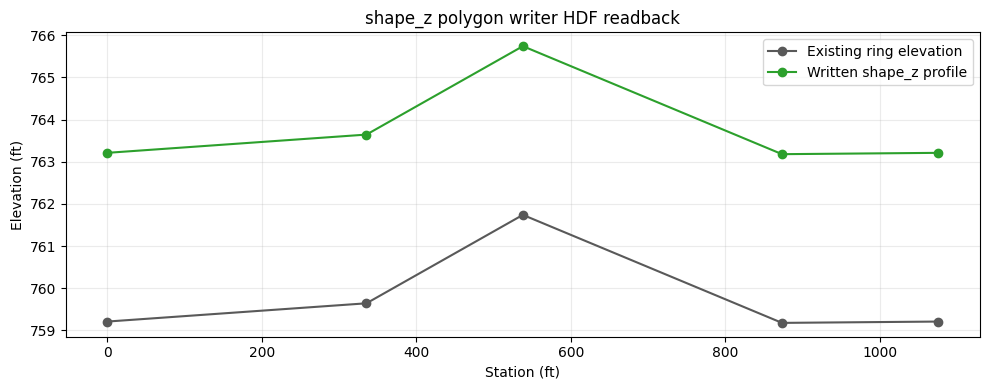

In [8]:
# Verify shape_z polygon writer HDF profile readback against ring Z values
shape_z_existing_closed = np.r_[
    shape_z_existing_ring_elevations,
    shape_z_existing_ring_elevations[0],
]
shape_z_readback = pd.DataFrame({
    'station': shape_z_profile_values[:, 0].astype(float),
    'existing_elevation': shape_z_existing_closed.astype(float),
    'readback_elevation': shape_z_profile_values[:, 1].astype(float),
    'expected_elevation': shape_z_expected.astype(float),
})
shape_z_readback['terrain_change_ft'] = (
    shape_z_readback['readback_elevation']
    - shape_z_readback['existing_elevation']
)
shape_z_readback['readback_minus_shape_z_ft'] = (
    shape_z_readback['readback_elevation']
    - shape_z_readback['expected_elevation']
)
shape_z_max_abs_diff = float(shape_z_readback['readback_minus_shape_z_ft'].abs().max())
shape_z_max_abs_change = float(shape_z_readback['terrain_change_ft'].abs().max())
assert shape_z_max_abs_diff <= 1e-6, (
    f'shape_z HDF profile readback differs from ring Z by {shape_z_max_abs_diff:.6f} ft'
)
assert shape_z_max_abs_change <= 10.0, (
    f'shape_z terrain change exceeds 10 ft: {shape_z_max_abs_change:.3f} ft'
)
assert shape_z_readback['terrain_change_ft'].min() >= 3.0
shape_z_stats = shape_z_readback[[
    'terrain_change_ft',
    'readback_minus_shape_z_ft',
]].describe().T
shape_z_stats['profile_points'] = len(shape_z_readback)
shape_z_stats['max_abs_ft'] = [
    shape_z_max_abs_change,
    shape_z_max_abs_diff,
]
display(shape_z_readback)
display(shape_z_stats)
print(f'shape_z HDF readback max abs diff: {shape_z_max_abs_diff:.6f} ft')
print(f'shape_z terrain change max abs diff: {shape_z_max_abs_change:.6f} ft')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    shape_z_readback['station'],
    shape_z_readback['existing_elevation'],
    marker='o',
    label='Existing ring elevation',
    color='0.35',
)
ax.plot(
    shape_z_readback['station'],
    shape_z_readback['readback_elevation'],
    marker='o',
    label='Written shape_z profile',
    color='tab:green',
)
ax.set_xlabel('Station (ft)')
ax.set_ylabel('Elevation (ft)')
ax.set_title('shape_z polygon writer HDF readback')
ax.legend()
ax.grid(True, alpha=0.25)
shape_z_profile_png = ARTIFACT_ROOT / 'shape_z_polygon_readback_validation.png'
fig.tight_layout()
fig.savefig(shape_z_profile_png, dpi=160)
shape_z_profile_png


,cell_terrain_difference_ft
count,5198.000000
mean,0.049019
std,0.538554
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,6.000000


WindowsPath('G:/GH/ras-commander/examples/example_projects/316_terrain_modifications/terrain_difference_map.png')

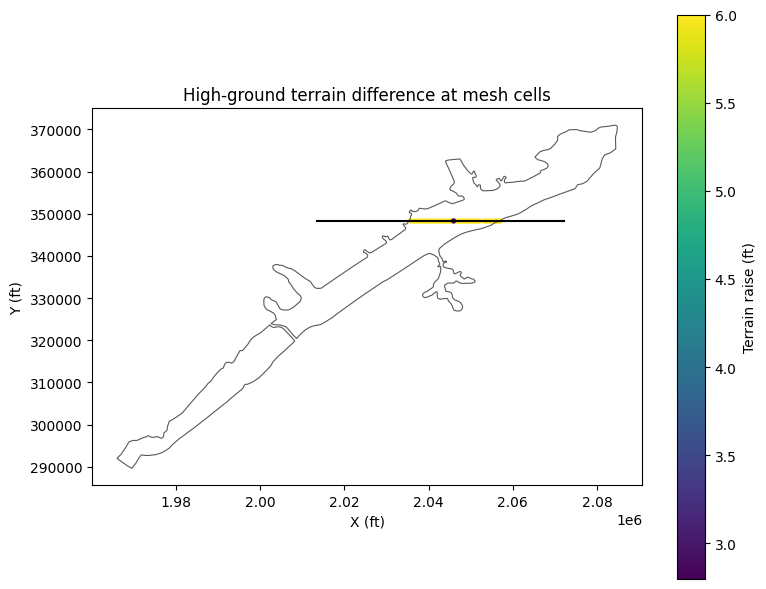

In [9]:
# Terrain difference map at geometry cell-center points
cell_points = HdfMesh.get_mesh_cell_points(base_geom_hdf)
cell_elev = pd.DataFrame({
    'mesh_name': cell_points['mesh_name'],
    'cell_id': cell_points['cell_id'],
    'x': cell_points.geometry.x,
    'y': cell_points.geometry.y,
})
cell_probe = RasTerrainModWriter.sample_modification_surface(
    proposed_terrain_hdf,
    'API High Ground Levee',
    cell_elev[['x', 'y']],
)
cell_existing = np.interp(
    cell_probe['line_station'],
    baseline_profile['station'],
    baseline_profile['elevation'],
)
cell_mod = RasTerrainModWriter.sample_modification_surface(
    proposed_terrain_hdf,
    'API High Ground Levee',
    cell_elev[['x', 'y']],
    existing_elevations=cell_existing,
)
terrain_map = pd.concat(
    [cell_elev[['mesh_name', 'cell_id']], cell_mod],
    axis=1,
)
terrain_map_stats = terrain_map['difference'].describe().to_frame('cell_terrain_difference_ft')
display(terrain_map_stats)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = terrain_map[terrain_map['difference'] > 0.01]
mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.35')
sc = ax.scatter(plot_df['x'], plot_df['y'], c=plot_df['difference'], s=8, cmap='viridis')
ax.plot(profile_x, profile_y, color='black', linewidth=1.5)
ax.set_aspect('equal')
ax.set_title('High-ground terrain difference at mesh cells')
ax.set_xlabel('X (ft)')
ax.set_ylabel('Y (ft)')
fig.colorbar(sc, ax=ax, label='Terrain raise (ft)')
terrain_png = ARTIFACT_ROOT / 'terrain_difference_map.png'
fig.tight_layout()
fig.savefig(terrain_png, dpi=160)
terrain_png

In [10]:
# Run HEC-RAS base, high-ground, multipoint polygon, and shape_z polygon plans through ras-commander
def force_clean_plan_inputs(project_path):
    for stale in project_path.glob('*.g11.hdf'):
        stale.unlink()
    for stale in project_path.glob('*.c18'):
        stale.unlink()

compute_rows = []
for label, project_path, ras_obj in [
    ('base', base_project, base_ras),
    ('high-ground proposed', proposed_project, proposed_ras),
    ('polygon proposed', polygon_project, polygon_ras),
    ('shape_z polygon proposed', shape_z_project, shape_z_ras),
]:
    force_clean_plan_inputs(project_path)
    result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras_obj,
        force_geompre=True,
        force_rerun=True,
        num_cores=2,
        verify=True,
    )
    compute_rows.append({
        'condition': label,
        'success': bool(result),
        'plan_hdf': str(project_path / 'BaldEagleDamBrk.p18.hdf'),
    })
compute_summary = pd.DataFrame(compute_rows)
assert compute_summary['success'].all(), 'One or more HEC-RAS plan computations failed'
compute_summary


,condition,success,plan_hdf
0,base,True,G:\GH\ras-commander\examples\example_projects\...
1,high-ground proposed,True,G:\GH\ras-commander\examples\example_projects\...
2,polygon proposed,True,G:\GH\ras-commander\examples\example_projects\...
3,shape_z polygon proposed,True,G:\GH\ras-commander\examples\example_projects\...


## Interpreting Benefit/Rise Areas

This is a benefits evaluation demonstration, not a conclusion that the evaluated terrain change has net benefits. `HdfBenefitAreas` surfaces calculated spatial differences between the existing and proposed plan HDF results as benefit and adverse-impact polygons for professional review. The mapped downstream rise area in this high-ground example is an impact signal from the model results; it may reflect that the terrain change was not paired with detention/storage, or that the project footprint needs further refinement or mitigation review. Treat the polygons as an engineering screening layer that identifies where to investigate, not as a standalone design conclusion.


,result,features,cells,area_acres,min_wse_difference_ft,max_wse_difference_ft
0,benefit_polygons,1,73,381.28621,NaN,NaN
1,rise_polygons,1,832,4690.80324,NaN,NaN
2,difference_points,5198,905,NaN,-0.078979,0.246094


,scenario,min_wse_difference_ft,max_wse_difference_ft,mean_wse_difference_ft,max_abs_wse_difference_ft,cells_abs_gt_0_01_ft
0,high-ground proposed,-0.078979,0.246094,0.008088,0.246094,905
1,polygon proposed,-0.000488,0.002930,0.000051,0.002930,0
2,shape_z polygon proposed,0.000000,0.000000,0.000000,0.000000,0


high-ground proposed cells with |WSE difference| > 0.01 ft: 905
polygon proposed cells with |WSE difference| > 0.01 ft: 0
shape_z polygon proposed cells with |WSE difference| > 0.01 ft: 0


,artifact,path
0,wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
1,polygon_wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
2,shape_z_wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
3,benefit_rise_area_map.png,G:\GH\ras-commander\examples\example_projects\...


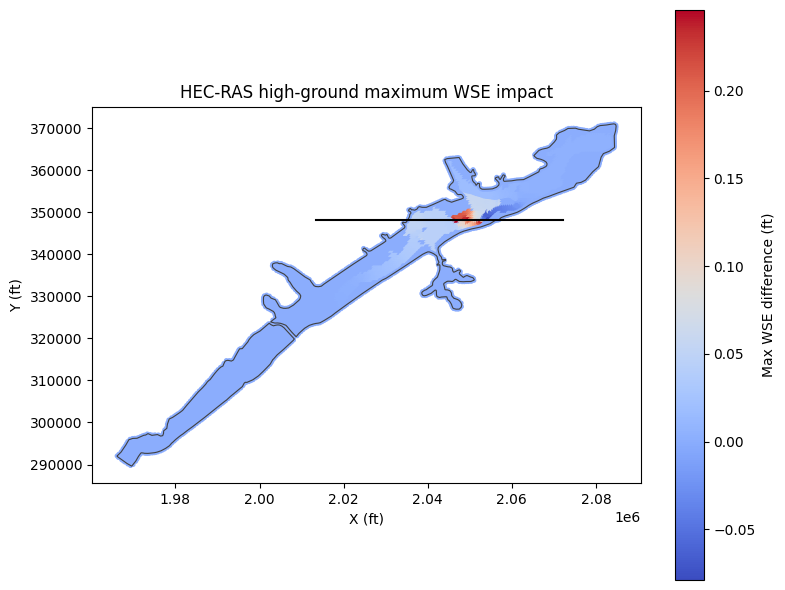

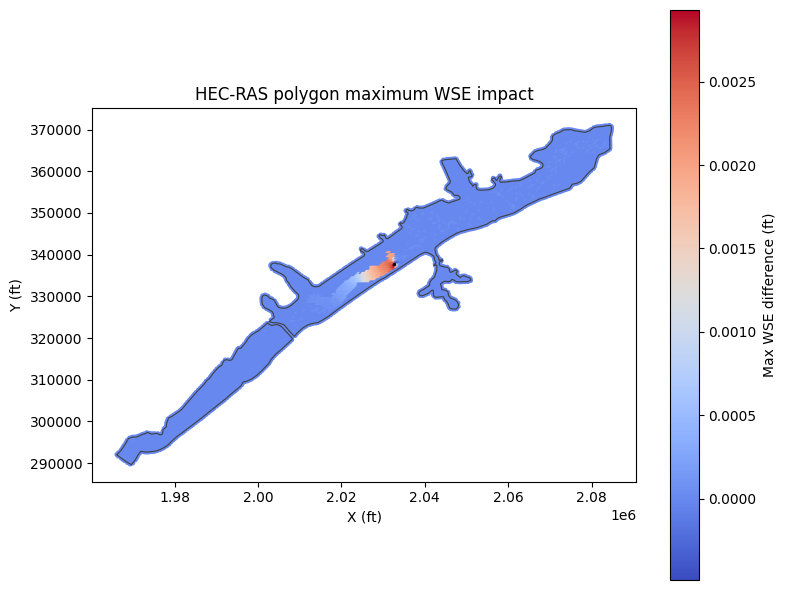

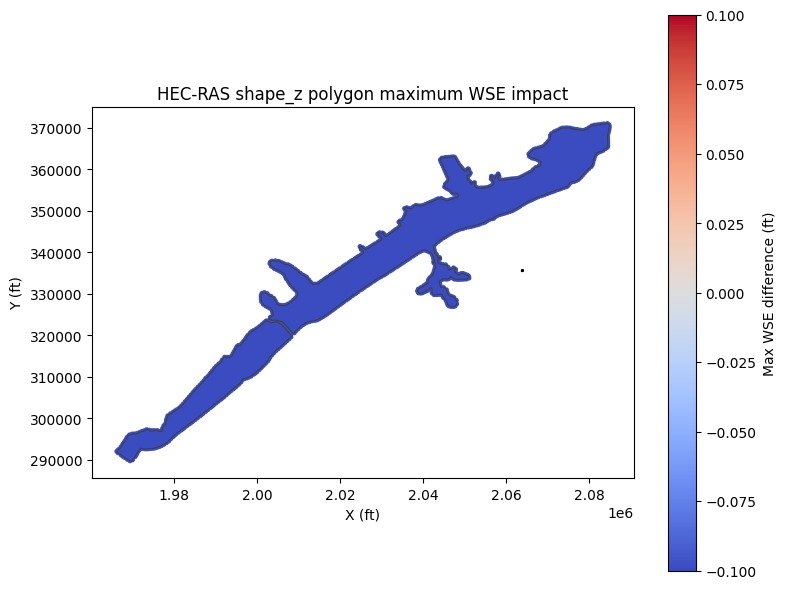

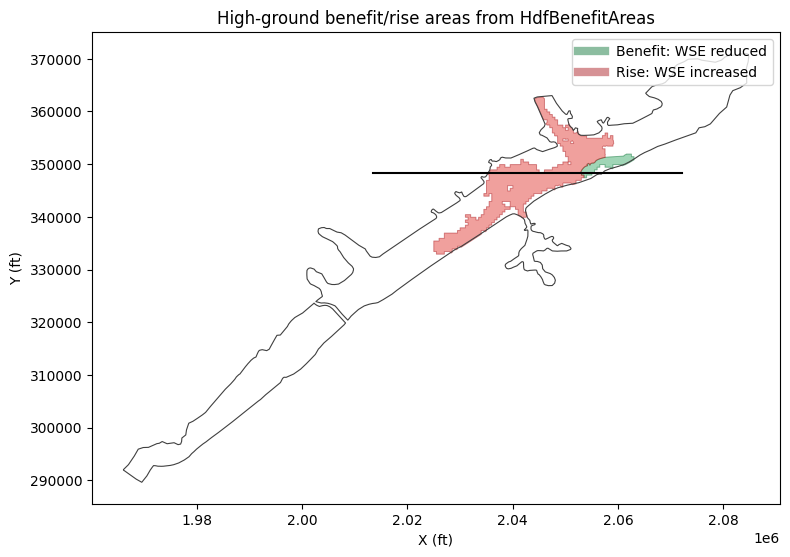

In [11]:
# Compare maximum water surface elevations from result HDF files
base_plan_hdf = base_project / 'BaldEagleDamBrk.p18.hdf'
proposed_plan_hdf = proposed_project / 'BaldEagleDamBrk.p18.hdf'
polygon_plan_hdf = polygon_project / 'BaldEagleDamBrk.p18.hdf'
shape_z_plan_hdf = shape_z_project / 'BaldEagleDamBrk.p18.hdf'
base_wse = HdfResultsMesh.get_mesh_max_ws(base_plan_hdf)

# HdfBenefitAreas packages the common existing/proposed comparison into
# reusable benefit/rise polygons plus matched point differences.
benefit_results = HdfBenefitAreas.identify_benefit_areas(
    existing_hdf_path=base_plan_hdf,
    proposed_hdf_path=proposed_plan_hdf,
    min_delta=0.01,
    adjacency_method='polygon_edges',
)


def benefit_area_summary(results):
    rows = []
    for label in ['benefit_polygons', 'rise_polygons']:
        gdf = results[label]
        rows.append({
            'result': label,
            'features': len(gdf),
            'cells': int(gdf['cell_count'].sum()) if not gdf.empty else 0,
            'area_acres': float(gdf['area_acres'].sum()) if not gdf.empty else 0.0,
            'min_wse_difference_ft': np.nan,
            'max_wse_difference_ft': np.nan,
        })
    diff = results['difference_points']
    rows.append({
        'result': 'difference_points',
        'features': len(diff),
        'cells': int((diff['wse_difference'].abs() >= 0.01).sum()),
        'area_acres': np.nan,
        'min_wse_difference_ft': float(diff['wse_difference'].min()),
        'max_wse_difference_ft': float(diff['wse_difference'].max()),
    })
    return pd.DataFrame(rows)


benefit_summary = benefit_area_summary(benefit_results)
display(benefit_summary)

# Use the API difference points for the high-ground map/summary; keep the manual
# helper below for the other terrain variants.
high_ground_wse = benefit_results['difference_points'].rename(columns={'geometry': 'geometry_base'})
high_ground_wse = high_ground_wse.set_geometry('geometry_base')


def wse_difference_from_base(plan_hdf, suffix):
    scenario_wse = HdfResultsMesh.get_mesh_max_ws(plan_hdf)
    result = base_wse.merge(
        scenario_wse,
        on=['mesh_name', 'cell_id'],
        suffixes=('_base', f'_{suffix}'),
    )
    result['wse_difference'] = (
        result[f'maximum_water_surface_{suffix}']
        - result['maximum_water_surface_base']
    )
    return result


polygon_wse = wse_difference_from_base(polygon_plan_hdf, 'polygon')
shape_z_wse = wse_difference_from_base(shape_z_plan_hdf, 'shape_z')
wse_scenarios = [
    ('high-ground proposed', high_ground_wse),
    ('polygon proposed', polygon_wse),
    ('shape_z polygon proposed', shape_z_wse),
]
wse_summary = pd.DataFrame([
    {
        'scenario': scenario,
        'min_wse_difference_ft': float(wse_df['wse_difference'].min()),
        'max_wse_difference_ft': float(wse_df['wse_difference'].max()),
        'mean_wse_difference_ft': float(wse_df['wse_difference'].mean()),
        'max_abs_wse_difference_ft': float(wse_df['wse_difference'].abs().max()),
        'cells_abs_gt_0_01_ft': int((wse_df['wse_difference'].abs() > 0.01).sum()),
    }
    for scenario, wse_df in wse_scenarios
])
display(wse_summary)
for scenario, wse_df in wse_scenarios:
    print(
        f'{scenario} cells with |WSE difference| > 0.01 ft:',
        int((wse_df['wse_difference'].abs() > 0.01).sum()),
    )


def plot_wse_difference(wse_df, title, output_path, overlay='line'):
    fig, ax = plt.subplots(figsize=(8, 6))
    wse_plot = wse_df[np.isfinite(wse_df['wse_difference'])].copy().set_geometry('geometry_base')
    wse_plot.plot(
        ax=ax,
        column='wse_difference',
        cmap='coolwarm',
        markersize=7,
        legend=True,
        legend_kwds={'label': 'Max WSE difference (ft)'},
    )
    mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.25')
    if overlay == 'line':
        ax.plot(profile_x, profile_y, color='black', linewidth=1.5)
    elif overlay == 'polygon':
        ax.plot(closed_polygon[:, 0], closed_polygon[:, 1], color='black', linewidth=1.5)
    elif overlay == 'shape_z_polygon':
        ax.plot(shape_z_closed_polygon[:, 0], shape_z_closed_polygon[:, 1], color='black', linewidth=1.5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('X (ft)')
    ax.set_ylabel('Y (ft)')
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    return output_path


def plot_benefit_rise_areas(results, output_path):
    fig, ax = plt.subplots(figsize=(8, 6))
    mesh_areas.boundary.plot(ax=ax, linewidth=0.8, color='0.25')
    handles = []
    benefit_gdf = results['benefit_polygons']
    rise_gdf = results['rise_polygons']
    if not benefit_gdf.empty:
        benefit_gdf.plot(ax=ax, facecolor='#2ca25f', edgecolor='#006d2c', alpha=0.45, linewidth=0.7)
        handles.append(plt.Line2D([0], [0], color='#006d2c', linewidth=6, alpha=0.45, label='Benefit: WSE reduced'))
    if not rise_gdf.empty:
        rise_gdf.plot(ax=ax, facecolor='#de2d26', edgecolor='#a50f15', alpha=0.45, linewidth=0.7)
        handles.append(plt.Line2D([0], [0], color='#a50f15', linewidth=6, alpha=0.45, label='Rise: WSE increased'))
    ax.plot(profile_x, profile_y, color='black', linewidth=1.5)
    if handles:
        ax.legend(handles=handles, loc='upper right')
    ax.set_aspect('equal')
    ax.set_title('High-ground benefit/rise areas from HdfBenefitAreas')
    ax.set_xlabel('X (ft)')
    ax.set_ylabel('Y (ft)')
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    return output_path


wse_png = ARTIFACT_ROOT / 'wse_difference_map.png'
polygon_wse_png = ARTIFACT_ROOT / 'polygon_wse_difference_map.png'
shape_z_wse_png = ARTIFACT_ROOT / 'shape_z_wse_difference_map.png'
benefit_rise_png = ARTIFACT_ROOT / 'benefit_rise_area_map.png'
plot_wse_difference(high_ground_wse, 'HEC-RAS high-ground maximum WSE impact', wse_png, overlay='line')
plot_wse_difference(polygon_wse, 'HEC-RAS polygon maximum WSE impact', polygon_wse_png, overlay='polygon')
plot_wse_difference(shape_z_wse, 'HEC-RAS shape_z polygon maximum WSE impact', shape_z_wse_png, overlay='shape_z_polygon')
plot_benefit_rise_areas(benefit_results, benefit_rise_png)
pd.DataFrame({
    'artifact': [
        'wse_difference_map.png',
        'polygon_wse_difference_map.png',
        'shape_z_wse_difference_map.png',
        'benefit_rise_area_map.png',
    ],
    'path': [str(wse_png), str(polygon_wse_png), str(shape_z_wse_png), str(benefit_rise_png)],
})


In [12]:
# Final artifact list for human review
pd.DataFrame({
    'artifact': [
        'terrain_profile_difference.png',
        'terrain_profile_readback_validation.png',
        'polygon_multipoint_control_points.png',
        'polygon_profile_readback_validation.png',
        'shape_z_polygon_readback_validation.png',
        'terrain_difference_map.png',
        'wse_difference_map.png',
        'polygon_wse_difference_map.png',
        'shape_z_wse_difference_map.png',
        'benefit_rise_area_map.png',
        'base plan HDF',
        'high-ground proposed plan HDF',
        'polygon proposed plan HDF',
        'shape_z proposed plan HDF',
        'shape_z terrain HDF',
    ],
    'path': [
        str(profile_png),
        str(readback_profile_png),
        str(polygon_points_png),
        str(polygon_profile_png),
        str(shape_z_profile_png),
        str(terrain_png),
        str(wse_png),
        str(polygon_wse_png),
        str(shape_z_wse_png),
        str(benefit_rise_png),
        str(base_plan_hdf),
        str(proposed_plan_hdf),
        str(polygon_plan_hdf),
        str(shape_z_plan_hdf),
        str(shape_z_terrain_hdf),
    ],
})


,artifact,path
0,terrain_profile_difference.png,G:\GH\ras-commander\examples\example_projects\...
1,terrain_profile_readback_validation.png,G:\GH\ras-commander\examples\example_projects\...
2,polygon_multipoint_control_points.png,G:\GH\ras-commander\examples\example_projects\...
3,polygon_profile_readback_validation.png,G:\GH\ras-commander\examples\example_projects\...
4,shape_z_polygon_readback_validation.png,G:\GH\ras-commander\examples\example_projects\...
5,terrain_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
6,wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
7,polygon_wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
8,shape_z_wse_difference_map.png,G:\GH\ras-commander\examples\example_projects\...
9,benefit_rise_area_map.png,G:\GH\ras-commander\examples\example_projects\...
